In [41]:
import os
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

### Функции для предобработки данных

In [42]:
# ПАРАМЕТРЫ
CHUNK_SIZE = 500 # Размер отрывков текста в словах
STEP_SIZE = 200 # Шаг для разбиения текстов на отрывки
EPOCHS = 30 
LR = 0.0069
BATCH_SIZE = 64
VAL_SIZE = 0.2 # доля валидационной выборки

### Классы датасета и персептрона

In [ ]:
# Чтение файла
def read_file(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        return f.read()
    
# Разбиение текста на отрывки
def chunk_text(text, chunk_size=200, step=200):
    tokens = text.split()
    chunks = []
    start = 0
    while start < len(tokens):
        chunk = tokens[start:start+chunk_size]
        if not chunk:
            break
        chunks.append(" ".join(chunk))
        start += step
    return chunks

# Функция для подготовки фиксированных чанков текста от разных авторов
def prepare_author_chunks(author_files, chunk_size=200, step=200):
    texts, labels, label2author = [], [], {}
    # Перебираем все файлы, соответствующие авторам
    for label_idx, filepath in enumerate(author_files):
        # Извлекаем имя автора из имени файла
        author_name = os.path.splitext(os.path.basename(filepath))[0]
        label2author[label_idx] = author_name
        # Разбиваем текст автора на чанки фиксированного размера и шага
        chunks = chunk_text(read_file(filepath), chunk_size, step)
        # Добавляем полученные чанки в общий список текстов
        texts.extend(chunks)
        # Добавляем соответствующую метку (label_idx) для каждого чанка
        labels.extend([label_idx] * len(chunks))

    # Возвращаем список текстов, список меток и отображение меток в имена авторов
    return texts, labels, label2author

### Классы датасета и персептрона

In [44]:
class TextDataset(Dataset):
    def __init__(self, X_vectors, y_labels):
        if hasattr(X_vectors, 'toarray'):
            X_vectors = X_vectors.toarray()
        self.X = torch.tensor(X_vectors, dtype=torch.float32)
        self.y = torch.tensor(y_labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=100, output_dim=6, dropout_rate=0.46):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

### Функции для обучения и предсказания

In [45]:
def train_model(model, train_loader, val_loader, epochs=5, lr=1e-3, device='cpu'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_val_acc, best_state_dict = 0.0, None

    for epoch in range(1, epochs+1):
        model.train()
        total_train_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)

        model.eval()
        val_loss, all_preds, all_targets = 0, [], []
        with torch.no_grad():
            for X, y in val_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                val_loss += criterion(outputs, y).item()
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(y.cpu().numpy())
        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(all_targets, all_preds)
        print(f"Epoch [{epoch}/{epochs}]: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}, Val Acc = {val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state_dict = model.state_dict()

    if best_state_dict:
        model.load_state_dict(best_state_dict)
    return model

def predict_text(model, vectorizer, text, chunk_size=200, step=200, device='cpu'):
    model.eval()
    chunks = chunk_text(text, chunk_size, step)
    if not chunks:
        return 0
    X = vectorizer.transform(chunks)
    X_torch = torch.tensor(X.toarray(), dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(X_torch)
        return torch.argmax(logits.sum(dim=0)).item()


### Подготовка данных: загрузка текстов, нарезка чанков

In [46]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

author_files = ["Fry.txt", "Genri.txt", "Simak.txt", "Bulgakov.txt", "Bradbury.txt", "Strugatskie.txt"]
path_to_files = "texts/"
full_paths = [os.path.join(path_to_files, filename) for filename in author_files]
texts, labels, label2author = prepare_author_chunks(full_paths, CHUNK_SIZE, STEP_SIZE)
num_classes = len(label2author)

print("Всего чанков (фрагментов) после нарезки:", len(texts))

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=VAL_SIZE, random_state=42, stratify=labels)
print(f"Train chunks: {len(train_texts)}, Val chunks: {len(val_texts)}")

Using device: cuda
Всего чанков (фрагментов) после нарезки: 9188
Train chunks: 7350, Val chunks: 1838


### Визуализация распределения чанков и примеры текста

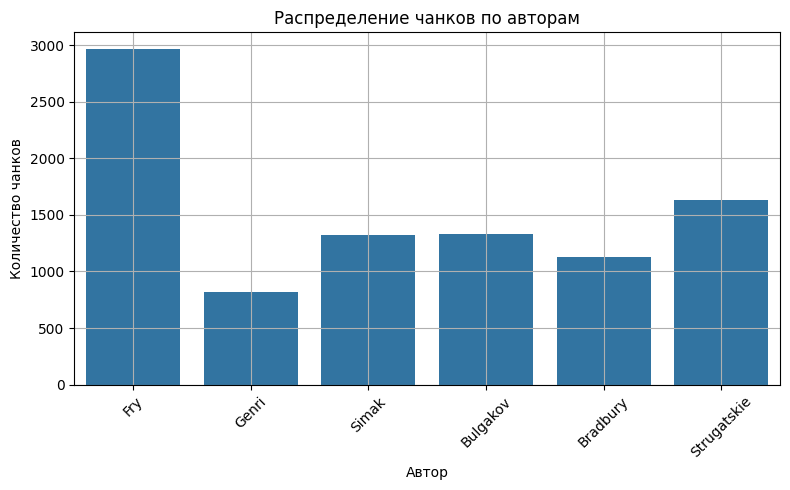

In [47]:
# Визуализация распределения чанков по авторам
label_counts = Counter(labels)
author_names = [label2author[i] for i in sorted(label2author)]

plt.figure(figsize=(8, 5))
sns.barplot(x=author_names, y=[label_counts[i] for i in range(len(author_names))])
plt.title("Распределение чанков по авторам")
plt.xlabel("Автор")
plt.ylabel("Количество чанков")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [48]:
# Вывод примеров чанков для каждого автора
for i in range(len(label2author)):
    sample_idx = labels.index(i)
    print(f"Автор: {label2author[i]}")
    print(texts[sample_idx])
    print("-" * 80)

Автор: Fry
﻿Власть несбывшегося – С тех пор как меня угораздило побывать в этой грешной Черхавле, мне ежедневно снится какая-то дичь! – сердито сказал я Джуффину. – Сглазили они меня, что ли? А собственно, почему бы и нет!.. – Я даже не стану тратить драгоценное время на то, чтобы тебя успокаивать: ты и сам отлично понимаешь, что метешь чушь! – улыбнулся шеф, заботливо пододвигая ко мне кружку с горячей камрой. – Просто ты не любишь, когда тебя будят на рассвете, и первые полчаса готов ворчать по любому поводу, как старый хрыч, предчувствующий приближение очередного приступа ревматизма… Никто тебя не сглазил, и так называемая дичь снится тебе отнюдь не ежедневно. Ну разве что сегодня, если не врешь… И поделом, между прочим! Нечего так беззастенчиво дрыхнуть на рабочем месте. – Все претензии к внезапно угомонившимся друзьям вашей бурной юности, – проворчал я. – Я же не виноват, что они больше не хотят совершать всякие ужасные преступления. Чем только не приходится заниматься, чтобы не р

### Обучение модели

In [49]:
# Векторизация текстов
vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1,2), analyzer='word', token_pattern=r'\w+')
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)

train_dataset = TextDataset(X_train, train_labels)
val_dataset = TextDataset(X_val, val_labels)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

input_dim = X_train.shape[1]
model = MLP(input_dim, hidden_dim=74, output_dim=num_classes).to(device)

print("\n--- Обучение модели ---")
model = train_model(model, train_loader, val_loader, EPOCHS, LR, device)

# Оценка на валидационной выборке
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X, y in val_loader:
        X, y = X.to(device), y.to(device)
        preds = torch.argmax(model(X), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y.cpu().numpy())

val_acc = accuracy_score(all_true, all_preds)
print("\n=== Итоговая оценка на валидационной выборке ===")
print(f"Val Accuracy: {val_acc:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(all_true, all_preds))
print("\nClassification Report:")
print(classification_report(all_true, all_preds, target_names=[label2author[i] for i in range(num_classes)]))


--- Обучение модели ---
Epoch [1/30]: Train Loss = 0.5206, Val Loss = 0.0329, Val Acc = 0.9935
Epoch [2/30]: Train Loss = 0.0198, Val Loss = 0.0079, Val Acc = 0.9989
Epoch [3/30]: Train Loss = 0.0068, Val Loss = 0.0056, Val Acc = 0.9989
Epoch [4/30]: Train Loss = 0.0034, Val Loss = 0.0043, Val Acc = 0.9989
Epoch [5/30]: Train Loss = 0.0022, Val Loss = 0.0031, Val Acc = 0.9995
Epoch [6/30]: Train Loss = 0.0016, Val Loss = 0.0025, Val Acc = 0.9995
Epoch [7/30]: Train Loss = 0.0012, Val Loss = 0.0025, Val Acc = 0.9995
Epoch [8/30]: Train Loss = 0.0013, Val Loss = 0.0024, Val Acc = 0.9995
Epoch [9/30]: Train Loss = 0.0011, Val Loss = 0.0029, Val Acc = 0.9989
Epoch [10/30]: Train Loss = 0.0007, Val Loss = 0.0020, Val Acc = 0.9995
Epoch [11/30]: Train Loss = 0.0008, Val Loss = 0.0040, Val Acc = 0.9989
Epoch [12/30]: Train Loss = 0.0006, Val Loss = 0.0026, Val Acc = 0.9995
Epoch [13/30]: Train Loss = 0.0006, Val Loss = 0.0025, Val Acc = 0.9995
Epoch [14/30]: Train Loss = 0.0005, Val Loss = 0

### Тестирование

In [50]:
# Классификация 21 тестового отрывка на уже обученной модели
df = pd.read_csv("author_classification.csv")
test_true = []
test_pred = []

test_files_dir = "texts/"

print("\n--- Классификация тестовых файлов (на уже обученной модели) ---")
for _, row in df.iterrows():
    fname = os.path.join(test_files_dir, row['filename'])
    true_author = row['author']
    
    if not os.path.exists(fname):
        print(f"Файл {fname} не найден, пропуск...")
        continue
    
    text = read_file(fname)
    pred_label = predict_text(model, vectorizer, text, chunk_size=CHUNK_SIZE, step=STEP_SIZE, device=device)
    pred_author = label2author[pred_label]
    
    test_true.append(true_author)
    test_pred.append(pred_author)
    
    print(f"Файл {fname} -> предсказанный автор: {pred_author} (истинный: {true_author})")

print("\n=== Оценка на 21 тестовом отрывке ===")
print("Accuracy:", accuracy_score(test_true, test_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(test_true, test_pred, labels=list(label2author.values())))
print("\nClassification Report:")
print(classification_report(test_true, test_pred, labels=list(label2author.values())))


--- Классификация тестовых файлов (на уже обученной модели) ---
Файл texts/author1.txt -> предсказанный автор: Genri (истинный: Genri)
Файл texts/author2.txt -> предсказанный автор: Simak (истинный: Simak)
Файл texts/author3.txt -> предсказанный автор: Simak (истинный: Genri)
Файл texts/author4.txt -> предсказанный автор: Bulgakov (истинный: Bulgakov)
Файл texts/author5.txt -> предсказанный автор: Genri (истинный: Genri)
Файл texts/author6.txt -> предсказанный автор: Bradbury (истинный: Bradbury)
Файл texts/author7.txt -> предсказанный автор: Fry (истинный: Fry)
Файл texts/author8.txt -> предсказанный автор: Fry (истинный: Fry)
Файл texts/author9.txt -> предсказанный автор: Strugatskie (истинный: Strugatskie)
Файл texts/author10.txt -> предсказанный автор: Bradbury (истинный: Bradbury)
Файл texts/author11.txt -> предсказанный автор: Bulgakov (истинный: Bulgakov)
Файл texts/author12.txt -> предсказанный автор: Strugatskie (истинный: Bradbury)
Файл texts/author13.txt -> предсказанный ав